In [68]:
#коллекшн (мы скачали из сайта)
from google.colab import drive
drive.mount('/content/drive')

path = '/content/drive/MyDrive/diabetic_data.csv'
df = pd.read_csv(path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import GroupKFold

In [70]:
#дискрипшн
#size
print(f"size: {df.shape}")
print(f"rows: {df.shape[0]}")
print(f"columns: {df.shape[1]}")

#features
print("columns:")
print(list(df.columns))

#types
print("\ndata types:")
print(df.dtypes.value_counts())

if "patient_nbr" in df.columns:
    print(f"\nUnique patients: {df['patient_nbr'].nunique()}")
if "encounter_id" in df.columns:
    print(f"Unique encounters: {df['encounter_id'].nunique()}")

size: (101766, 50)
rows: 101766
columns: 50
columns:
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

data types:
object    37
int64     13
Name: count, dtype: int64

Unique patients: 71518
Unique encounters: 101766


In [ ]:
#клининг
print("Before cleaning:", df.shape)

# заменить ? на нан
df = df.replace("?", np.nan)

# проверить пустые
missing = df.isna().mean().sort_values(ascending=False)

# удалить неизвестный гендер
if "gender" in df.columns:
    invalid_count = (df["gender"] == "Unknown/Invalid").sum()
    df = df[df["gender"] != "Unknown/Invalid"]

# удалили колонну вес тк много пустых значений
if "weight" in df.columns:
    missing_weight = df["weight"].isna().mean()
    if missing_weight > 0.4:
        df = df.drop(columns=["weight"])

# хаменяет пустые мед спец на неизвестно
if "medical_specialty" in df.columns:
    df["medical_specialty"] = df["medical_specialty"].fillna("Unknown")

# перезапускает индексы
df.reset_index(drop=True, inplace=True)

print("\nAfter cleaning:", df.shape)

# проверяет корректность
assert not (df == "?").any().any(), "Still have '?' symbols!"
if "gender" in df.columns:
    assert not (df["gender"] == "Unknown/Invalid").any(), "Invalid gender values remain!"

Before cleaning: (101766, 50)

After cleaning: (101763, 49)


In [72]:
#трансформэйшн
# выбор признаков
feature_cols = [
    "race","gender","age",
    "admission_type_id","discharge_disposition_id","admission_source_id",
    "time_in_hospital","num_lab_procedures","num_procedures","num_medications",
    "number_outpatient","number_emergency","number_inpatient","number_diagnoses",
    "max_glu_serum","A1Cresult","change","diabetesMed"
]
X = df[feature_cols].copy()

# типы признаков
num_cols = X.select_dtypes(exclude="object").columns.tolist()
cat_cols = X.select_dtypes(include="object").columns.tolist()

# преобразования
num_tf = Pipeline([
    ("imp", SimpleImputer(strategy="median")),     # числовые пропуски
    ("sc", StandardScaler())                       # масштабирование
])

cat_tf = Pipeline([
    ("imp", SimpleImputer(strategy="most_frequent")),       # категориальные пропуски
    ("oh", OneHotEncoder(handle_unknown="ignore"))  # one-hot кодирование
])

preprocessor = ColumnTransformer([
    ("num", num_tf, num_cols),
    ("cat", cat_tf, cat_cols)
], sparse_threshold=0.3)  # оставить разреженный формат при необходимости

# k-best
k_best = 120  # можно скорректировать (пример: 80–200)
feature_selector = SelectKBest(score_func=mutual_info_classif, k=k_best)

# итоговый препроцессорный пайплайн
transformer = Pipeline([
    ("pre", preprocessor),
    ("to_dense",  # утилита для перевода sparse->dense только для селектора
     type("ToDense", (), {"fit": lambda self, X, y=None: self,
                          "transform": lambda self, X: X.toarray() if hasattr(X, "toarray") else X})()),
    ("fs", feature_selector)
])

# обучение трансформера
groups = df["patient_nbr"] if "patient_nbr" in df.columns else None
X_tr = transformer.fit_transform(X, y)

print("Transformed shape:", X_tr.shape)

# получение имён признаков после One-Hot (до селекции)
def get_ohe_feature_names(preprocessor, num_cols, cat_cols):
    # числовые имена — как есть
    num_names = list(num_cols)
    # категориальные имена — из OneHotEncoder
    oh = preprocessor.named_transformers_["cat"].named_steps["oh"]
    cat_names = oh.get_feature_names_out(cat_cols).tolist()
    return num_names + cat_names

full_feature_names = get_ohe_feature_names(transformer.named_steps["pre"], num_cols, cat_cols)

# имена отобранных признаков (после SelectKBest)
selected_mask = transformer.named_steps["fs"].get_support()
# учитываем, что перед fs мы перевели в dense; размерности совпадают с full_feature_names
selected_features = [name for name, keep in zip(full_feature_names, selected_mask) if keep]

print(f"Selected features (k={k_best}): {len(selected_features)}")
# показать первые 25 для краткости
selected_features[:25]


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:783: UserWarning: k=120 is greater than n_features=38. All the features will be returned.
  warnings.warn(


Transformed shape: (101763, 38)
Selected features (k=120): 38


['admission_type_id',
 'discharge_disposition_id',
 'admission_source_id',
 'time_in_hospital',
 'num_lab_procedures',
 'num_procedures',
 'num_medications',
 'number_outpatient',
 'number_emergency',
 'number_inpatient',
 'number_diagnoses',
 'race_AfricanAmerican',
 'race_Asian',
 'race_Caucasian',
 'race_Hispanic',
 'race_Other',
 'gender_Female',
 'gender_Male',
 'age_[0-10)',
 'age_[10-20)',
 'age_[20-30)',
 'age_[30-40)',
 'age_[40-50)',
 'age_[50-60)',
 'age_[60-70)']

/tmp/ipython-input-1968075226.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index.astype(str), y=counts.values, palette="Set2")


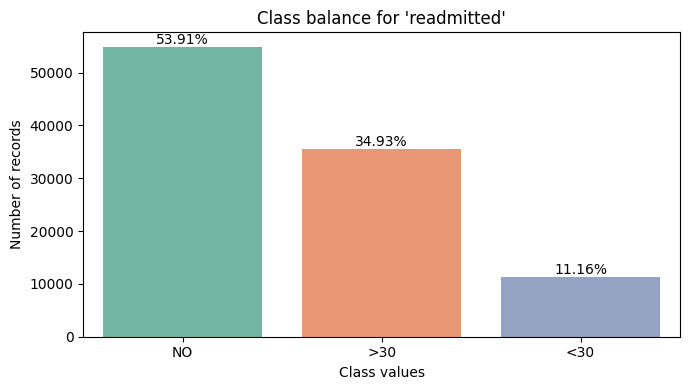

In [73]:
#поиск баланса
target_col = "readmitted"

# Проверим частоты
counts = df[target_col].value_counts(dropna=False)
percent = (counts / len(df) * 100).round(2)


# Визуализация
plt.figure(figsize=(7,4))
sns.barplot(x=counts.index.astype(str), y=counts.values, palette="Set2")
plt.title(f"Class balance for '{target_col}'")
plt.ylabel("Number of records")
plt.xlabel("Class values")
for i, v in enumerate(counts.values):
    plt.text(i, v + max(counts.values)*0.01, f"{percent.iloc[i]}%", ha='center', fontsize=10)
plt.tight_layout()
plt.show()


/tmp/ipython-input-116293263.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index.astype(str), y=counts.values, palette="Set2")


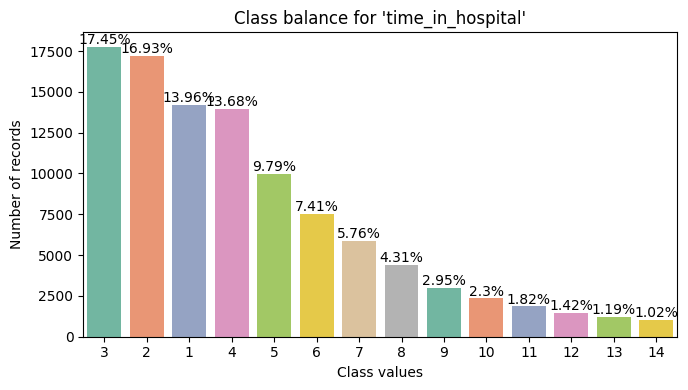

In [74]:
target_col = "time_in_hospital"

# Проверим частоты
counts = df[target_col].value_counts(dropna=False)
percent = (counts / len(df) * 100).round(2)


# Визуализация
plt.figure(figsize=(7,4))
sns.barplot(x=counts.index.astype(str), y=counts.values, palette="Set2")
plt.title(f"Class balance for '{target_col}'")
plt.ylabel("Number of records")
plt.xlabel("Class values")
for i, v in enumerate(counts.values):
    plt.text(i, v + max(counts.values)*0.01, f"{percent.iloc[i]}%", ha='center', fontsize=10)
plt.tight_layout()
plt.show()


/tmp/ipython-input-114044856.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index.astype(str), y=counts.values, palette="Set2")


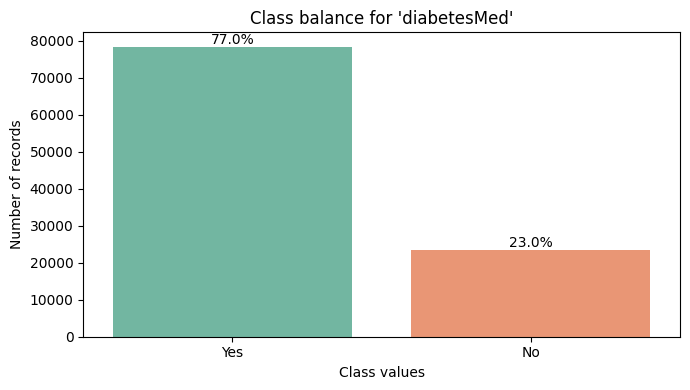

In [75]:
target_col = "diabetesMed"

# Проверим частоты
counts = df[target_col].value_counts(dropna=False)
percent = (counts / len(df) * 100).round(2)


# Визуализация
plt.figure(figsize=(7,4))
sns.barplot(x=counts.index.astype(str), y=counts.values, palette="Set2")
plt.title(f"Class balance for '{target_col}'")
plt.ylabel("Number of records")
plt.xlabel("Class values")
for i, v in enumerate(counts.values):
    plt.text(i, v + max(counts.values)*0.01, f"{percent.iloc[i]}%", ha='center', fontsize=10)
plt.tight_layout()
plt.show()


/tmp/ipython-input-2747974036.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index.astype(str), y=counts.values, palette="Set2")


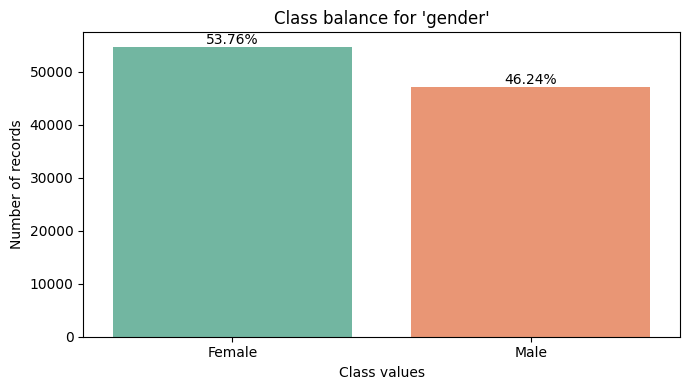

In [76]:
target_col = "gender"

# Проверим частоты
counts = df[target_col].value_counts(dropna=False)
percent = (counts / len(df) * 100).round(2)


# Визуализация
plt.figure(figsize=(7,4))
sns.barplot(x=counts.index.astype(str), y=counts.values, palette="Set2")
plt.title(f"Class balance for '{target_col}'")
plt.ylabel("Number of records")
plt.xlabel("Class values")
for i, v in enumerate(counts.values):
    plt.text(i, v + max(counts.values)*0.01, f"{percent.iloc[i]}%", ha='center', fontsize=10)
plt.tight_layout()
plt.show()


In [77]:
# тут мы смотрели сбалансированный ли датасет или нет
# по повторному попаданию в больницу, днях в больнице, получение терапии диабета - нет
# по гендеру - да
# лучшее решение дальше работать по гендеру
# хотя повторное поадание более важно чем гендер
# так что мы попробуем оба варика
#

,count,mean,std,min,25%,50%,75%,max
encounter_id,101763.0,1.652008e+08,1.026410e+08,12522.0,84959748.0,152388294.0,230269803.0,443867222.0
patient_nbr,101763.0,5.432965e+07,3.869658e+07,135.0,23412964.5,45500490.0,87545713.5,189502619.0
admission_type_id,101763.0,2.020000e+00,1.450000e+00,1.0,1.0,1.0,3.0,8.0
discharge_disposition_id,101763.0,3.720000e+00,5.280000e+00,1.0,1.0,1.0,4.0,28.0
admission_source_id,101763.0,5.750000e+00,4.060000e+00,1.0,1.0,7.0,7.0,25.0
time_in_hospital,101763.0,4.400000e+00,2.990000e+00,1.0,2.0,4.0,6.0,14.0
num_lab_procedures,101763.0,4.310000e+01,1.967000e+01,1.0,31.0,44.0,57.0,132.0
num_procedures,101763.0,1.340000e+00,1.710000e+00,0.0,0.0,1.0,2.0,6.0
num_medications,101763.0,1.602000e+01,8.130000e+00,1.0,10.0,15.0,20.0,81.0
number_outpatient,101763.0,3.700000e-01,1.270000e+00,0.0,0.0,0.0,0.0,42.0


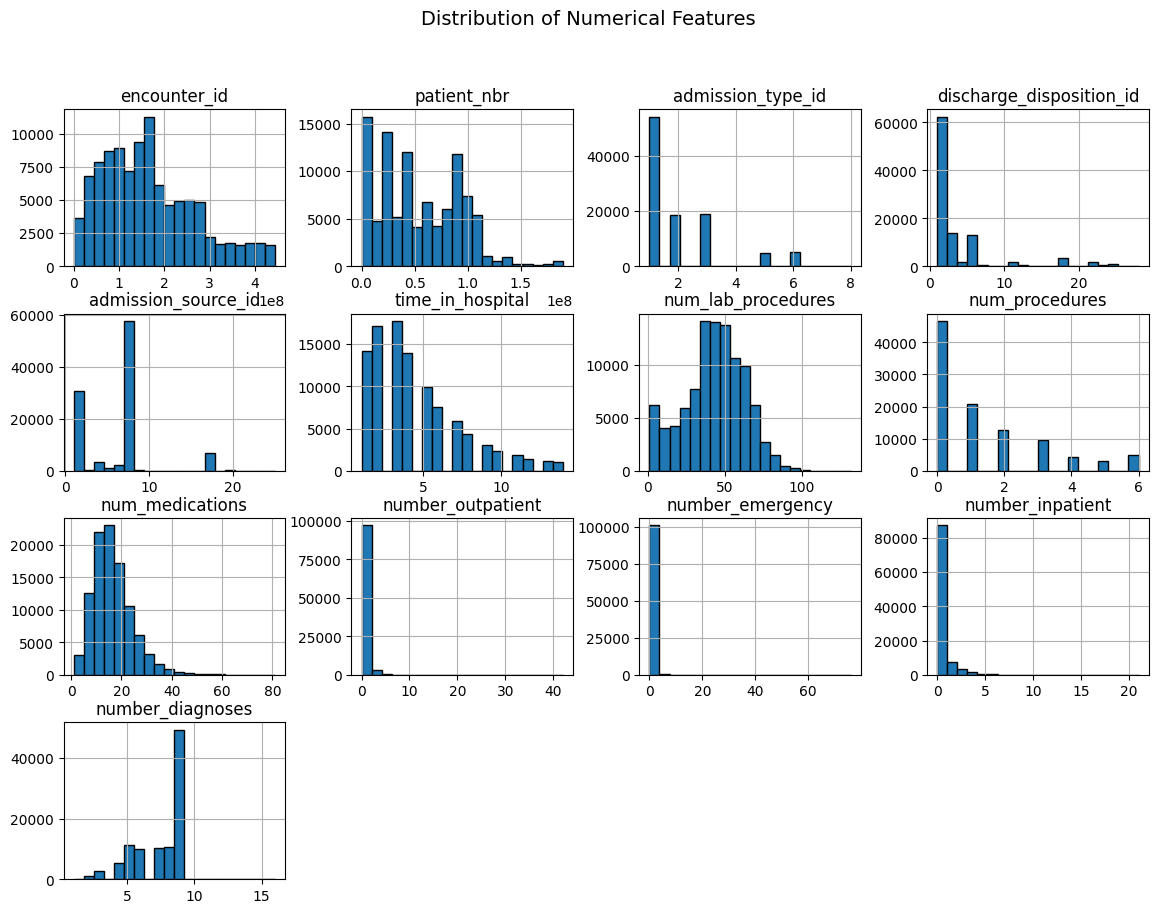

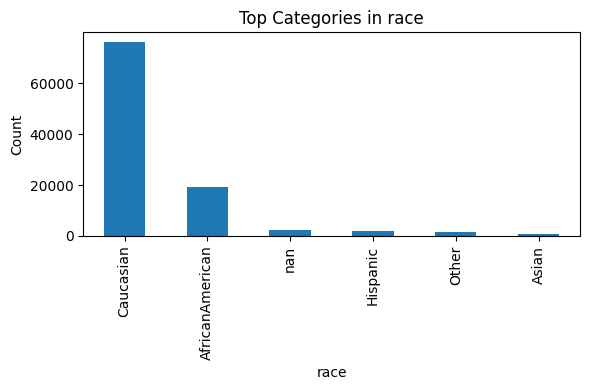

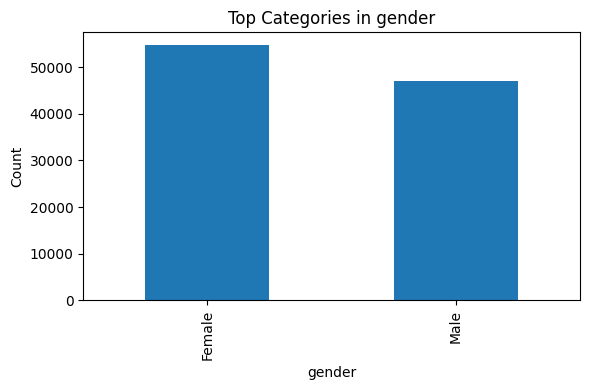

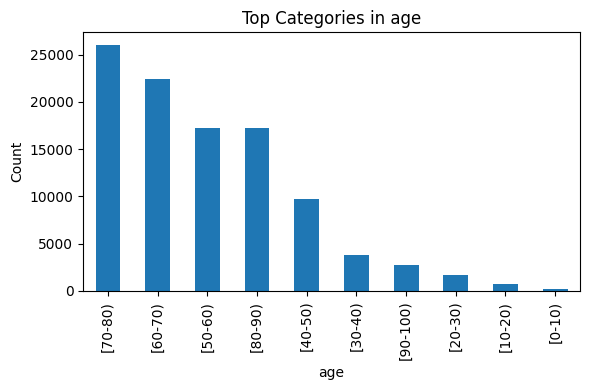

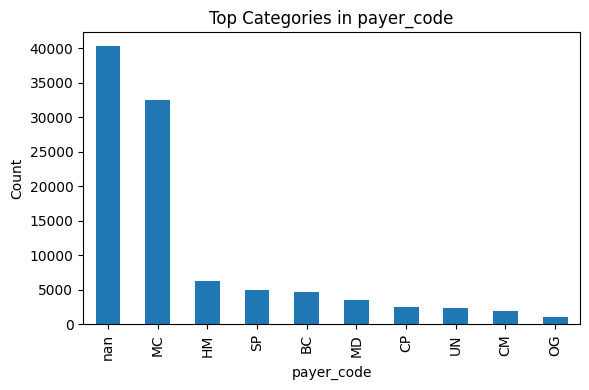

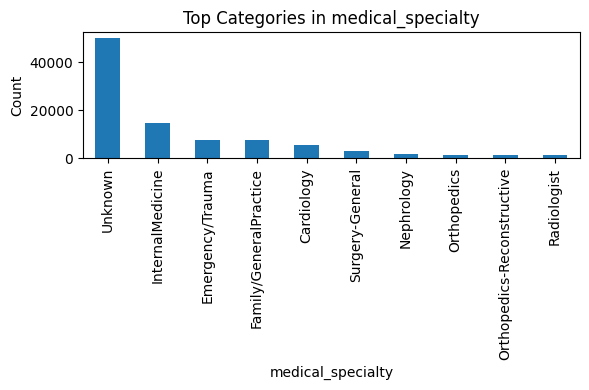

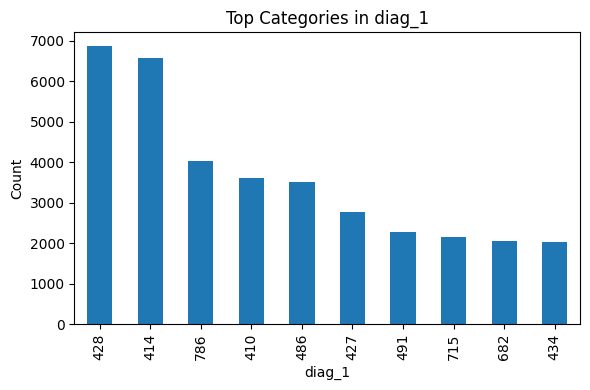

In [78]:
# статистикс
display(df.describe().T.round(2))

num_cols = df.select_dtypes(exclude="object").columns
df[num_cols].hist(figsize=(14,10), bins=20, edgecolor='black')
plt.suptitle("Distribution of Numerical Features", fontsize=14)
plt.show()

cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols[:6]:  # ограничим для компактности
    plt.figure(figsize=(6,4))
    df[col].value_counts(dropna=False).head(10).plot(kind='bar')
    plt.title(f"Top Categories in {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()



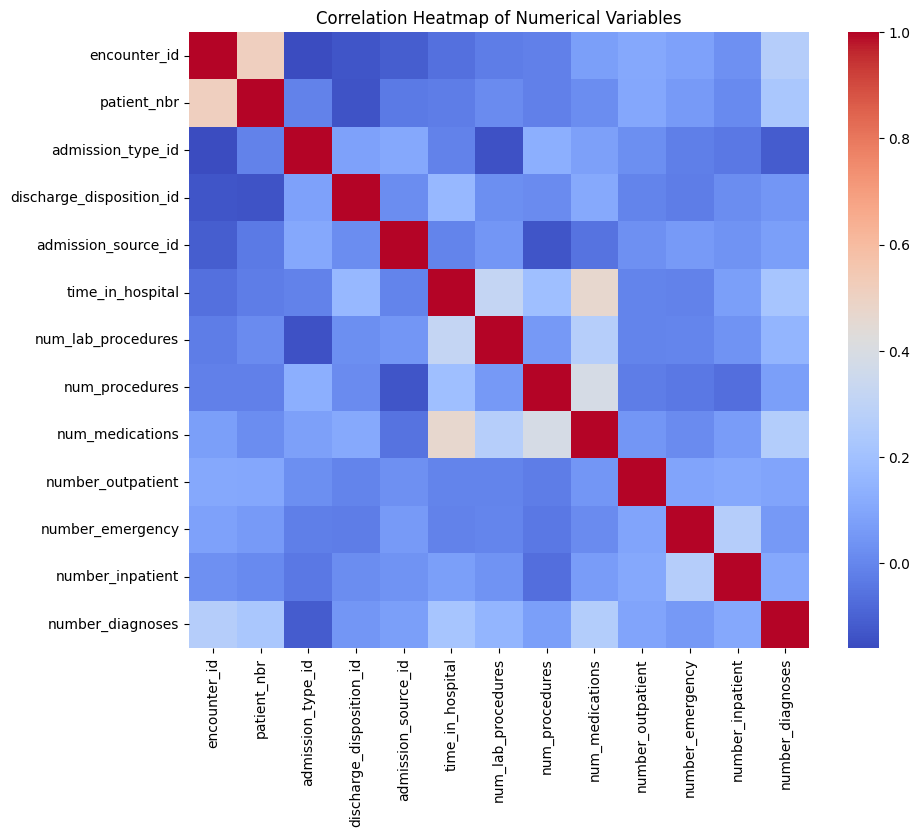

In [79]:
# корреляции
corr = df[num_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

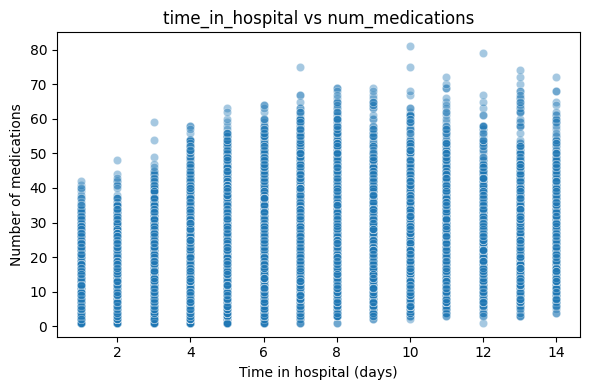

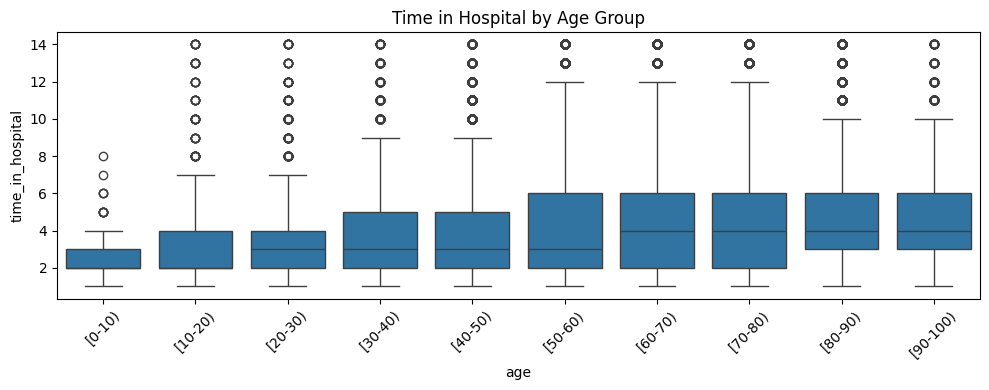

In [80]:
# скаттер плот
if "num_medications" in df.columns and "time_in_hospital" in df.columns:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x="time_in_hospital", y="num_medications", data=df, alpha=0.4)
    plt.title("time_in_hospital vs num_medications")
    plt.xlabel("Time in hospital (days)")
    plt.ylabel("Number of medications")
    plt.tight_layout()
    plt.show()

# бокс мап
if "time_in_hospital" in df.columns and "age" in df.columns:
    plt.figure(figsize=(10,4))
    sns.boxplot(x="age", y="time_in_hospital", data=df)
    plt.title("Time in Hospital by Age Group")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


/tmp/ipython-input-4107511742.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="age", y="num_medications", data=df, inner="quartile", palette="Spectral")


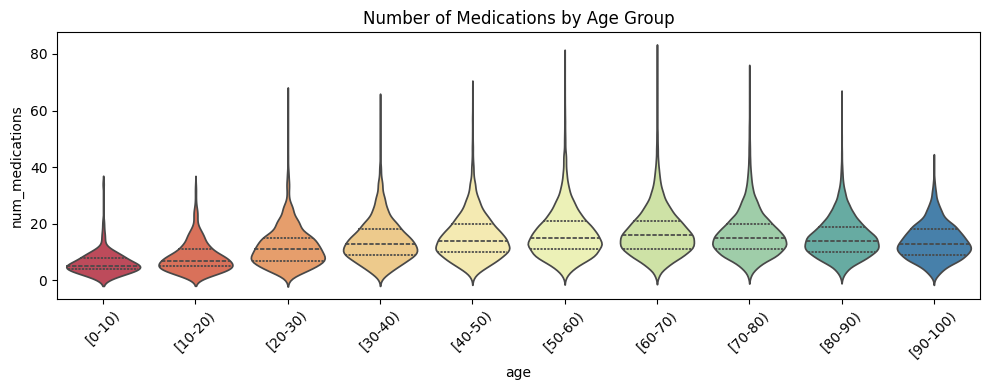

In [81]:
# вайолин мап
if {"age", "num_medications"}.issubset(df.columns):
    plt.figure(figsize=(10,4))
    sns.violinplot(x="age", y="num_medications", data=df, inner="quartile", palette="Spectral")
    plt.title("Number of Medications by Age Group")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()